# Does everything is at the stationnary state at the same time?

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))
from tools import *
from macro import *

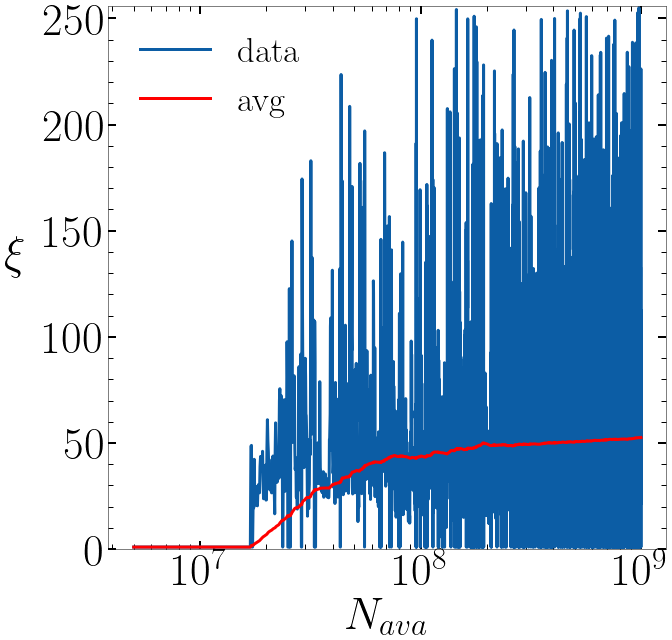

/home/kduplat/Documents/Data/Pscript/tools.py:124: RuntimeWarning: overflow encountered in exp
  return a * np.exp(-b * x)


In [8]:
folder = '/data1/DATA_Duplat/Brut/PDF/PD1n10'
params = read_parameters(folder)
L1 = params[0]
L2 = params[1]
nu = params[2]
iniava = params[-3][0]
deltaava = params[-3][1]


nbava = 0
limcorr = 0


with open (f"{folder}/save_B.txt") as f:
    lines = f.readlines()
    
    for line in lines:
        if line.strip() == '' or line.strip().startswith('#'):
            continue
        
        match = re.match(r"([\d\.\+\-eE]+)\s+#Nav", line)
        if match :
            nbava = int(match.group(1))
            break

if nbava > (read_parameters(folder)[-1][1] * 10):
    limcorr = read_parameters(folder)[-1][1] * 10
else :
    limcorr = nbava
    
startmean = limcorr - (limcorr - iniava)*0.1

        
        
clentab , avgtab = corrlength(folder, iniava, deltaava, nbava, L2, switch_plot = 0, numcol = 3)
clentabfit , avgtabfit = corrlengthfit(folder, L2, iniava, deltaava, clentab, switch_plot = 1, numcol = 3)
b = meancorrfct(folder, deltaava, iniava, L1,L2, limcorr, clentab, startmean, numcol = 3, switch_plot=0)



In [9]:
def process_size_bis(histo, Lengthtab, nbins, nmin, nmax):

    last_non_zero = np.nonzero(histo)[0]
    
    mean = np.sum(histo * np.arange(len(histo)))/np.sum(histo)
    
    ndatafit, ndistloglog, nstat = mainfct(histo, Lengthtab, nbins, nmin, nmax)
    Tndist = 10 ** ndistloglog
    Tndatafit = 10 ** ndatafit
    Tnstat = nstat[0]
    
    return Tndist, Tndatafit, Tnstat, last_non_zero[-1], mean

(10,)
(10,)


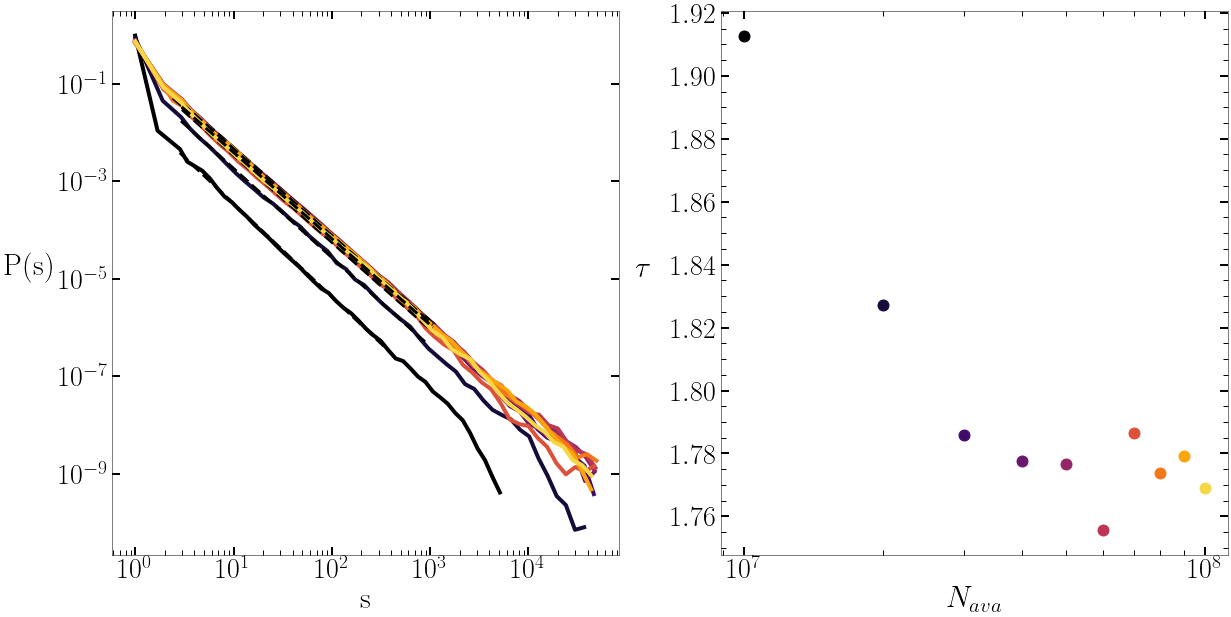

In [10]:
nbins = 50
nmin = 2
nmax = 30

nu = params[2]
lengthtab = L1 * L2

data = read_gz_with_pandas(f"{folder}/trans_histosize.gz")
nbhisto = int(len(data)/(L1 * L2))
data = np.reshape(data, (nbhisto, (L1 * L2 + 1)) )


time = np.array([params[-1][2] * (i+1) for i in range(int(params[-1][1]/params[-1][2]))])
selected_points = np.arange(len(time))

print(np.shape(time))
print(np.shape(selected_points))

# selected_points = [0,1,2,3,4,5, 6, 7, 8, 9]
# time = time[selected_points]

Tnmin = np.array([nmin] * nbhisto)
Tnmax = np.array([nmax] * nbhisto)

results = Parallel(n_jobs=-1)(delayed(process_size_bis)(histo, lengthtab, nbins, nmin, nmax)
                                  for (histo, nmin, nmax) in zip(data, Tnmin, Tnmax))

Tndist = np.zeros((nbhisto,nbins, 2))
Tnstat = np.zeros(nbhisto)
Tnonzero = np.zeros(nbhisto)
Tmean = np.zeros(nbhisto)
Tndatafit = np.zeros((nbhisto,2,2))

NCURVES = nbhisto
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize=(20,10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)
for j, (Tndist_j, Tndatafit_j, Tnstat_j, Tnzero_j, mean_j) in enumerate(results):
    if j in selected_points:
        Tndist[j] = Tndist_j
        Tndatafit[j] = Tndatafit_j
        Tnstat[j] = Tnstat_j    
        Tnonzero[j] = Tnzero_j
        Tmean[j] = mean_j
        ax1.plot(Tndist[j, :,0][Tndist[j, :,1] != 1],Tndist[j, :,1][Tndist[j, :,1] != 1], color = colors[j], linewidth=4, markersize=6, mfc="none") 
        ax1.plot(Tndatafit[j,:, 0], Tndatafit[j, :,1], color = 'k', linestyle = '--', linewidth = 3)
        ax2.scatter( time[j], -Tnstat[j], color = colors[j], s = 120)
            
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel('s', fontsize=30)
ax1.set_ylabel('P(s) ', fontsize=30, rotation = 0, labelpad = 30)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xscale("log")
ax2.set_xlabel(macros['Nava'], fontsize=30)
ax2.set_ylabel(r'$\tau$', fontsize=30, rotation = 0, labelpad = 30)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
""" plt.legend(title_fontsize = 23, ncol = 2, loc='center left', bbox_to_anchor=(1, 0.5),fontsize = 25) """
plt.show()

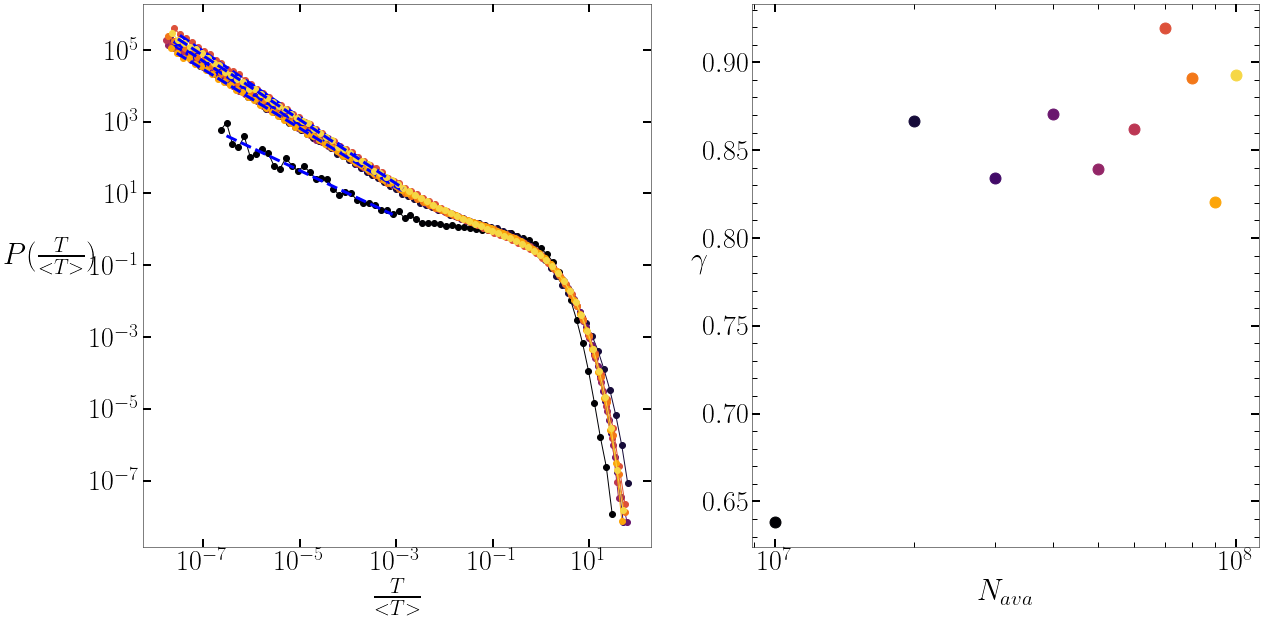

In [16]:
nbins = 1000
data = read_gz_with_pandas(f"{folder}/trans_histoitime.gz")

lim_trans = params[-1][1]
delta_trans = params[-1][2]
nbhisto = int(lim_trans/delta_trans)

histo = np.reshape(data, (nbhisto, nbins))
bins = np.logspace(np.log10(10**-12), np.log10(2), nbins + 1)
bin_centers = np.array([(bins[:-1] + bins[1:]) / 2] * nbhisto)

mean =  np.array([np.sum(histo[i] * bin_centers[i]) / np.sum(histo[i]) for i in range(nbhisto)])

norm_histo = np.array([histo[i]/((np.diff(bins)) * np.sum(histo[i])) for i in range(nbhisto)])
norm_histo = np.array([norm_histo[i] * mean[i] for i in range(nbhisto)])

norm_bin_centers = np.array([bin_centers[i]/mean[i] for i in range(nbhisto)])

# selected_points = [0, 1, 3, 5, 7, 9, 11, 50,  100, 450, 499]
# selected_points = [0,1,2,3,4,5,10, 20,30,40,49]
# selected_points = [0,1,2,3,4,5, 7, 8, 9]
selected_points = np.arange(nbhisto)
norm_histo = norm_histo[selected_points]
norm_bin_centers = norm_bin_centers[selected_points]

time = np.array([params[-1][2] * (i+1) for i in range(int(params[-1][1]/params[-1][2]))])
time = time[selected_points]


Tnmin = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
Tnmax = np.array([30, 30, 40, 40, 40, 40, 40, 40, 40, 40, 40])

NCURVES = len(norm_histo)
cmap = plt.cm.get_cmap('inferno')
colors = [cmap(i / NCURVES) for i in range(NCURVES)]

plt.figure(figsize = (20, 10))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

for j, (bins, histo) in enumerate(zip(norm_bin_centers, norm_histo)):
    
    bins_reduced, histo_reduced = change_bins_log_histo(bins, histo, 100)

    mask = histo_reduced!=0

    ax1.plot(bins_reduced[:-1][mask], histo_reduced[mask], color = colors[j], marker = "o")
    
    try:
        mask2 = histo_reduced[Tnmin[j]:Tnmax[j]] != 0
        popt2, _ = curve_fit(powerlaw2, np.log(bins_reduced[Tnmin[j]:Tnmax[j]][mask2]), np.log(histo_reduced[Tnmin[j]:Tnmax[j]][mask2]))
        a2,b2 = popt2
        yfit2 = np.exp(powerlaw2(np.log(bins_reduced[Tnmin[j]:Tnmax[j]]), *popt2))
        
        ax1.plot(bins_reduced[Tnmin[j]:Tnmax[j]], yfit2, linestyle = "--", color = 'b', linewidth = 3)
        
        ax2.scatter(time[j], -b2, color  = colors[j], s = 120)
    
    except ValueError:
        continue

ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_xlabel(r'$\frac{T}{<T>}$', fontsize = 30)
ax1.set_ylabel(r'$P(\frac{T}{<T>})$', fontsize = 30, rotation = 0,labelpad= 40)
ax1.tick_params(labelsize = 28,length = 8, width = 2)
ax1.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')

ax2.set_xlabel(r'$N_{ava}$', fontsize = 30)
ax2.set_ylabel(r'$\gamma$', fontsize = 30, rotation = 0)
ax2.tick_params(labelsize = 28,length = 8, width = 2)
ax2.set_xscale('log')
ax2.tick_params(labelsize = 28,length = 5, width = 1, which = 'minor')
plt.show()